# Import necessary modules

In [1]:
import torch
import torch.nn.functional as F
from torch import nn
from torch import Tensor
from torchvision.transforms import Compose, Resize, ToTensor
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import make_grid

import os
import time
import pandas as pd
import numpy as np
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt

# Install timm to access ViT PyTorch Models

In [2]:
pip install '../input/timm034/timm-0.3.4-py3-none-any.whl'

Processing /kaggle/input/timm034/timm-0.3.4-py3-none-any.whl
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/kaggle/input/timm034/timm-0.3.4-py3-none-any.whl'

Note: you may need to restart the kernel to use updated packages.


# Import timm

In [3]:
import timm

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

# Display Available Vision Transformer Models

In [4]:
print("Available ViT Models: ")
timm.list_models("vit*")

Available ViT Models: 


['vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_224',
 'vit_base_patch16_rope_ape_224',
 'vit_base_patch16_rope_mixed_224',
 'vit_base_patch16_rope_mixed_ape_224',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip_gap_512',
 'vit_base_patch16_xp_224',
 'vit_base_patch32_224',
 'vit_base_patch32_384'

In [5]:
data_path  = '../input/cassava-leaf-disease-classification/'
train_path = '../input/cassava-leaf-disease-classification/train_images/'
test_path  = '../input/cassava-leaf-disease-classification/test_images/'
model_path = '../input/vitbase16224/jx_vit_base_p16_224-80ecf9dd.pth'
Cassava_model = '../input/cassavapretrained4epoch/CassavaViT4epoch.pt'

# Define ViTBase 16 class

In [6]:
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):
        
        super(ViTBase16, self).__init__()
        
        self.model = timm.create_model("vit_base_patch16_224", pretrained=False)
        
        if pretrained:
            self.model.load_state_dict(torch.load(model_path))
            
        self.model.head = nn.Linear(self.model.head.in_features, n_classes)
    
    def forward(self, x):
        x = self.model(x)
        return x

# Create cassava pre-trained ViTBase16 model instance (5 classes)

In [7]:
cassava_model = ViTBase16(n_classes=5, pretrained=True)
cassava_model.load_state_dict(torch.load(Cassava_model))
cassava_gpu_model = cassava_model.cuda()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cassava_gpu_model.parameters(), lr=1.5e-05)
cassava_gpu_model

FileNotFoundError: [Errno 2] No such file or directory: '../input/vitbase16224/jx_vit_base_p16_224-80ecf9dd.pth'

# Examine test image folder

In [8]:
test_img_names = []
for folder, subfolders, filenames in os.walk(test_path):
    print('************************************************FOLDER************************************************')
    print(folder)
    print('************************************************IMAGES************************************************')
    for img in filenames:
        print(img)
        if img[-3:] == 'jpg':
            test_img_names.append(img)        
print('Testing Images: ',len(test_img_names))

************************************************FOLDER************************************************
../input/cassava-leaf-disease-classification/test_images/
************************************************IMAGES************************************************
2574872277.jpg
1449210447.jpg
1269550303.jpg
1411799307.jpg
2474336811.jpg
2513489893.jpg
138763396.jpg
1454379342.jpg
135606795.jpg
244091101.jpg
1305931861.jpg
2431640165.jpg
262767997.jpg
2562280265.jpg
1249688756.jpg
1382842589.jpg
135254587.jpg
2516383896.jpg
1238159478.jpg
125088495.jpg
1286327974.jpg
2584374846.jpg
2654269519.jpg
1383656888.jpg
2491752039.jpg
1339403533.jpg
1427622404.jpg
1390241299.jpg
1292206670.jpg
2568890447.jpg
2646704086.jpg
1465524436.jpg
2496742167.jpg
135225385.jpg
1323186666.jpg
2638836659.jpg
1401653529.jpg
1337727597.jpg
1238413001.jpg
1335010337.jpg
2653303226.jpg
2509293643.jpg
1282714006.jpg
1454355649.jpg
1335049078.jpg
248784600.jpg
2536601960.jpg
2575899944.jpg
1364299181.jpg
264063852

# Create class to load test data (adds image names)

In [9]:
class TestSet2(Dataset):
    """Cassava Disease Dataset"""

    def __init__(self, root_dir, test_dir, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with test image names.
            root_dir (string): Directory with all the test images.
            transform (callable, optional): Optional transform to be applied
            on a sample.
        """
        super().__init__()
        self.root_dir = root_dir
        self.test_dir = test_dir
        self.transform = transform
        print(root_dir)
        print(test_dir)
        print("Cassava Disease Test Dataset Length = ", len(os.listdir(self.test_dir)))


    def __len__(self):
        return len(os.listdir(self.test_dir))


    def __getitem__(self, idx):
        img_path = self.test_dir + os.listdir(self.test_dir)[idx] 
        img = Image.open(img_path).convert("RGB")
        image_name = os.listdir(self.test_dir)[idx]

        
        if self.transform:
            image = self.transform(img)
    
        return (image, image_name)

# Create test transforms (needed for image resizing)

In [10]:
test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

# Create test dataset

In [11]:
testset = TestSet2(root_dir = '' , test_dir=test_path, transform = test_transform)
print(testset)


../input/cassava-leaf-disease-classification/test_images/
Cassava Disease Test Dataset Length =  2677


# Load the test dataset

In [12]:
test_batch_size = 1
test_loader = DataLoader(dataset=testset, batch_size=test_batch_size, shuffle=True, pin_memory=True)

# Check to see if test_loader is working

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


('2494405997.jpg',)


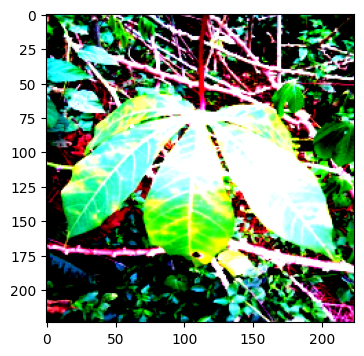

In [13]:
print(test_loader)

# Grab the first batch of 16 images
for images,names in test_loader: 
    break

im = make_grid(images, nrow=4)  # the default nrow is 8

# Inverse normalize the images
#inv_normalize = transforms.Normalize(
#    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
#    std=[1/0.229, 1/0.224, 1/0.225]
#)
#im_inv = inv_normalize(im)
print(names)
# Print the images
plt.figure(figsize=(12,4))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)));

# Used trained model to generate test data predictions
# Generate submission file

In [14]:
test_losses = []
test_correct = []
col_names =  ['image_id', 'label']
submission_df = pd.DataFrame(columns = col_names)
tic = time.time()
with torch.no_grad():
    for b, (X_test, name) in enumerate(test_loader):
        X_test = X_test.cuda()
        # Apply the model
        y_test_pred = cassava_gpu_model(X_test)
        predicted = torch.max(y_test_pred.data, 1)[1]
        label = int(predicted)
        image_name = name[0]
        new_row = {'image_id': image_name, 'label': label}
        submission_df = submission_df.append(new_row, ignore_index=True)
        
toc = time.time() - tic
print('Time for model val is ', toc)
#display(submission_df)
submission_df.to_csv('submission.csv', index=False)
df_sub_test = pd.read_csv('submission.csv')
display(df_sub_test)
!ls

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx